In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
import sys
sys.path.append(os.path.abspath('..'))
import traceback

import pandas as pd
import torch
from tqdm import tqdm

from models.networks import ConceptBottleneckModel
from models.metrics import evaluate_mse
from utils.data_utils import create_dataloaders
from config import get_config
from models.test import test
from matplotlib import pyplot as plt
from analysis.util import get_lambda_list_for_horizon

In [4]:
def calc_in_sample_mse(horizon, weight_lambda):
    """
    Calculate in-sample MSE for a given prediction horizon and concept bottleneck loss weight (lambda).
    Returns the average MSE over all train_date grid.

    Args:
        horizon (str): Prediction horizon, e.g., '1month', '3month', etc.
        weight_lambda (float or str): The lambda value for concept bottleneck loss.
    Returns:
        pd.Series: Mean MSE for each variable (index: variable name)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input = pd.read_csv(f'../data/input_{horizon}.csv')
    target = pd.read_csv(f'../data/target_{horizon}.csv')
    input['date']  = pd.to_datetime(input['date'])
    target['date'] = pd.to_datetime(target['date'])
    signal_info = pd.read_csv('../data/info/SignalDoc.csv')
    info = signal_info[signal_info['Acronym'].isin(input.columns)]

    # train_dates grid as used in run.py
    train_dates = [
        '2011-01-01', '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01', 
        '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01', '2020-01-01'
        ]

    mse_list = []
    for train_date in train_dates:
        autoencoder_path = f'../checkpoints/{horizon}_{weight_lambda}/{train_date}_autoencoder_model0.pt'
        config = get_config(weight_lambda)
        try:
            train_loader, _, _, _, _ = create_dataloaders(
                input, target, info, train_date, train_date, train_date, batch_size=config['batch_size'],
                embedding_method = 'autoencoder', model_path = autoencoder_path
            )
            model_dir = f'../checkpoints/{horizon}_{weight_lambda}'
            models = []
            for i in range(config['ensemble']):
                model = ConceptBottleneckModel(
                    config['input_size'], config['concept_hidden_sizes'], config['concept_output_size'],
                    config['final_hidden_sizes'], config['final_output_size']
                ).to(device)
                model_path = os.path.join(model_dir, f"{train_date}model_{i}.pt")
                model.load_state_dict(torch.load(model_path, map_location=device))
                model.eval()
                models.append(model)
            actual_concept, actual_target, forecast_concept, forecast_target = test(
                models, train_loader, config['ensemble'], device
            )
            mse = evaluate_mse(
                actual_concept, actual_target, forecast_concept, forecast_target, info
            )
            mse_list.append(mse)
        except Exception as e:
            print(f"{train_date} calculation failed: {e}")
            continue
    if len(mse_list) == 0:
        raise RuntimeError('In-sample MSE calculation failed for all train_dates.')
    # Average over multiple Series
    mse_df = pd.concat(mse_list, axis=1)
    mse_df.columns = train_dates
    mse_df['Whole periods'] = mse_df.mean(axis=1)
    return mse_df

In [5]:
def plot_mse(horizon, mode='oos', lambda_list = None):
    """
    Plot out-of-sample MSE for different lambda settings
    
    Parameters:
    -----------
    horizon : str
         Prediction horizon prefix in filename (e.g., '1month', '3month', '6month', '12month')
    mode : str, optional
         'oos' for out-of-sample MSE, 'is' for in-sample MSE. Default is 'oos'.
    lambda_list : list of float, optional
         List of lambda values to use for in-sample MSE calculation. Required when mode='is'.
    """

    # Set academic-style plotting parameters
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 15,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 2,
        'lines.markersize': 6,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })
    
    whole_periods = pd.DataFrame()

    if mode == 'oos':
        for file in os.listdir('../results'):
            if file.startswith(horizon) and file.endswith('mse.csv'):
                try:
                    lambda_part = file.replace(f'{horizon}_', '').replace('_mse.csv', '')
                    weight_lambda = float(lambda_part)
                    path = os.path.join('../results', file)
                    result = pd.read_csv(path)
                    whole_periods[weight_lambda] = result['Whole periods']
                except (ValueError, IndexError) as e:
                    print(f"Warning: Could not parse lambda value from filename '{file}': {e}")
                    continue
        whole_periods.index = result['Unnamed: 0']
        # Remove the "Consensus average MSE" row since it's not needed for plotting
        whole_periods = whole_periods.drop('Consensus average MSE', errors='ignore')
        
        # Sort the columns (lambda values) in ascending order
        whole_periods = whole_periods.reindex(sorted(whole_periods.columns), axis=1)
        
    elif mode == 'is':
        for weight_lambda in tqdm(lambda_list, desc="In-sample MSE by lambda"):
            try:
                mse_df = calc_in_sample_mse(horizon, weight_lambda)
                # Save to CSV in oos format
                out_path = f'../results/{horizon}_{weight_lambda}_is_mse.csv'
                mse_df.to_csv(out_path, index=True)
                # For plotting, you can still use the mean if needed
                whole_periods[weight_lambda] = mse_df['Whole periods']
            except Exception as e:
                print(f"lambda={weight_lambda} calculation failed: {e}")
                traceback.print_exc()

    if whole_periods.empty:
        print(f"No valid MSE files found for horizon '{horizon}'")
        return

    display(whole_periods)

    # Create separate plots for asset returns and consensus variables
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Define academic color palette
    colors = ['#2E86AB', '#A23B72']  # Professional blue and burgundy
    
    # Plot 1: Asset Returns (last row)
    ax1.plot(whole_periods.columns, whole_periods.iloc[-1], '--', 
             color=colors[0], linewidth=2, markersize=6, 
             markerfacecolor=colors[0], markeredgecolor='black', markeredgewidth=0.5)
    ax1.grid(True, alpha=0.3, linewidth=0.5)
    ax1.set_xlabel('Hyperparameter (λ)')
    if mode == 'oos':
        ax1.set_ylabel('Out-of-Sample MSE')
    elif mode == 'is':
        ax1.set_ylabel('In-Sample MSE')
    ax1.set_title('Asset Returns', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Plot 2: Consensus Variables (second to last row - consensus average)
    ax2.plot(whole_periods.columns, whole_periods.iloc[-2], '--', 
             color=colors[1], linewidth=2, markersize=6,
             markerfacecolor=colors[1], markeredgecolor='black', markeredgewidth=0.5)
    ax2.grid(True, alpha=0.3, linewidth=0.5)
    ax2.set_xlabel('Hyperparameter (λ)')
    if mode == 'oos':
        ax2.set_ylabel('Out-of-Sample MSE')
    elif mode == 'is':
        ax2.set_ylabel('In-Sample MSE')
    ax2.set_title('Consensus Variables', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    plt.close()

Plotting MSE for 1-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,0.306640,0.302494,0.302046,0.301308,0.300290,0.299142,0.298016,0.297019,0.296054,0.295059,...,0.286323,0.286325,0.286248,0.286201,0.286195,0.286175,0.286180,0.286207,0.286213,0.286203
Change in recommendation,0.333128,0.329948,0.329805,0.329774,0.329746,0.329752,0.329753,0.329713,0.329714,0.329758,...,0.329527,0.329546,0.329539,0.329548,0.329556,0.329588,0.329598,0.329606,0.329609,0.329615
Change in Forecast and Accrual,0.311624,0.293056,0.292232,0.291214,0.290231,0.289187,0.288250,0.287472,0.286838,0.285951,...,0.278170,0.278195,0.278179,0.278145,0.278163,0.278164,0.278155,0.278171,0.278172,0.278172
Long-vs-short EPS forecasts,0.336481,0.332642,0.331389,0.329674,0.327643,0.325415,0.323292,0.321158,0.319630,0.317632,...,0.300235,0.300151,0.300022,0.299879,0.299841,0.299873,0.299845,0.299787,0.299828,0.299781
Analyst earnings per share,0.338248,0.321764,0.311425,0.298425,0.281585,0.264222,0.249434,0.235303,0.221579,0.206569,...,0.070235,0.069789,0.069335,0.068894,0.068581,0.068349,0.067996,0.067848,0.067542,0.067286
EPS Forecast Dispersion,0.338465,0.329302,0.325176,0.320512,0.313877,0.306873,0.297952,0.289284,0.282684,0.273259,...,0.185062,0.184601,0.184273,0.183969,0.183693,0.183401,0.183058,0.182825,0.182488,0.182193
Earnings forecast revisions,0.335255,0.331697,0.330040,0.327519,0.324575,0.321655,0.319380,0.316894,0.315791,0.313012,...,0.271420,0.271117,0.270901,0.270666,0.270457,0.270097,0.269769,0.269563,0.269232,0.269101
Analyst Value,0.335944,0.327637,0.323795,0.319364,0.313749,0.307413,0.300399,0.293008,0.288260,0.280785,...,0.193299,0.192786,0.192479,0.192090,0.191717,0.191158,0.190836,0.190506,0.190141,0.189804
Analyst Optimism,0.338088,0.330626,0.327367,0.322574,0.316263,0.309849,0.302181,0.293851,0.286274,0.277661,...,0.189306,0.188871,0.188414,0.187910,0.187572,0.187249,0.186908,0.186663,0.186278,0.186010


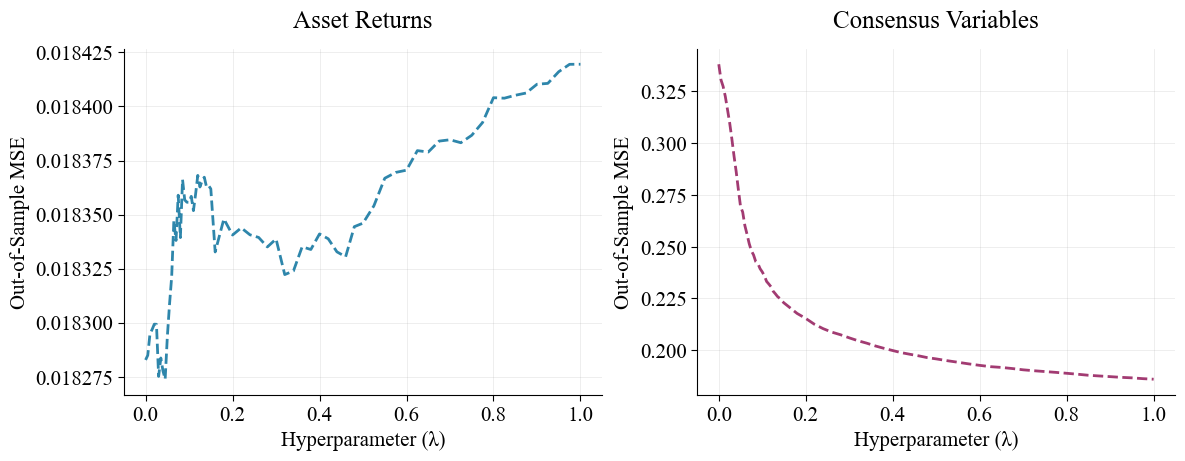

Plotting MSE for 3-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,0.312554,0.303159,0.302529,0.302040,0.301708,0.301114,0.300771,0.300338,0.299916,0.299481,...,0.286645,0.286584,0.286538,0.286475,0.286406,0.286352,0.286301,0.286280,0.286240,0.286228
Change in recommendation,0.340319,0.331511,0.330562,0.330314,0.330212,0.330112,0.330074,0.330051,0.330017,0.329984,...,0.329703,0.329697,0.329692,0.329710,0.329704,0.329697,0.329710,0.329692,0.329690,0.329694
Change in Forecast and Accrual,0.342902,0.296012,0.293657,0.292528,0.291868,0.291492,0.291020,0.290578,0.290164,0.289969,...,0.278433,0.278353,0.278280,0.278323,0.278234,0.278186,0.278141,0.278130,0.278068,0.278033
Long-vs-short EPS forecasts,0.338949,0.333342,0.331896,0.330839,0.329815,0.328917,0.328056,0.327117,0.326246,0.325335,...,0.299965,0.299842,0.299762,0.299643,0.299658,0.299585,0.299467,0.299454,0.299453,0.299418
Analyst earnings per share,0.345317,0.323577,0.316804,0.310047,0.304622,0.297321,0.292454,0.285574,0.278940,0.270654,...,0.078606,0.077861,0.077209,0.076545,0.075950,0.075449,0.074769,0.074351,0.073955,0.073546
EPS Forecast Dispersion,0.342378,0.329016,0.325579,0.323002,0.320095,0.316770,0.314131,0.310928,0.307767,0.304028,...,0.192939,0.192457,0.191949,0.191470,0.191030,0.190665,0.190174,0.189755,0.189278,0.188832
Earnings forecast revisions,0.339708,0.331250,0.329769,0.328314,0.326944,0.325652,0.324493,0.323365,0.322156,0.320752,...,0.274238,0.273847,0.273554,0.273224,0.272943,0.272658,0.272365,0.272051,0.271823,0.271613
Analyst Value,0.343474,0.328321,0.325588,0.322738,0.320274,0.317982,0.315501,0.312560,0.309493,0.307463,...,0.202326,0.201587,0.200955,0.200091,0.199376,0.198784,0.198147,0.197567,0.197103,0.196506
Analyst Optimism,0.339885,0.331185,0.328456,0.325768,0.323121,0.320326,0.317702,0.314728,0.311487,0.308089,...,0.196592,0.195964,0.195453,0.194625,0.193979,0.193376,0.192825,0.192445,0.192028,0.191631


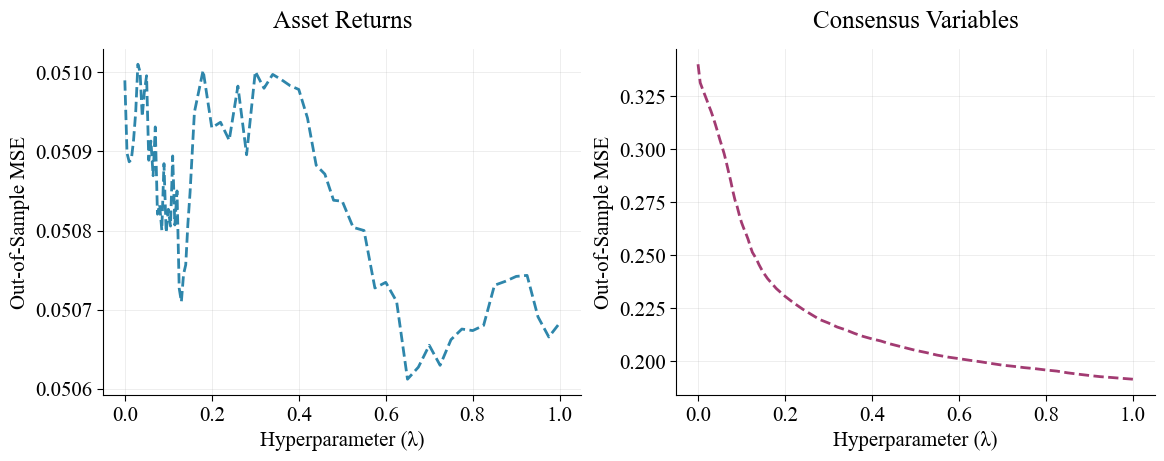

Plotting MSE for 6-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,0.320254,0.306806,0.303807,0.302576,0.301934,0.301348,0.301025,0.300579,0.300327,0.299973,...,0.287575,0.287413,0.287324,0.287271,0.287174,0.287108,0.287006,0.286943,0.286875,0.286795
Change in recommendation,0.354804,0.335995,0.331893,0.331452,0.330874,0.330797,0.330703,0.330619,0.330583,0.330531,...,0.330149,0.330128,0.330101,0.330126,0.330111,0.330094,0.330072,0.330062,0.330055,0.330044
Change in Forecast and Accrual,0.441165,0.314375,0.298830,0.295294,0.293434,0.292627,0.291928,0.291389,0.290985,0.290568,...,0.279551,0.279412,0.279326,0.279274,0.279178,0.279096,0.278985,0.278972,0.278904,0.278854
Long-vs-short EPS forecasts,0.342988,0.335726,0.332378,0.330814,0.329618,0.328645,0.327939,0.327017,0.326489,0.325688,...,0.301800,0.301580,0.301520,0.301399,0.301280,0.301122,0.300988,0.300861,0.300846,0.300784
Analyst earnings per share,0.353710,0.324054,0.313684,0.307128,0.302110,0.296972,0.293013,0.288893,0.284607,0.279766,...,0.086255,0.085274,0.084438,0.083724,0.082889,0.081937,0.081094,0.080523,0.079956,0.079494
EPS Forecast Dispersion,0.346523,0.333106,0.324110,0.320616,0.317119,0.314190,0.311790,0.309497,0.307418,0.305870,...,0.198652,0.198142,0.197399,0.196938,0.196569,0.195910,0.195325,0.194900,0.194751,0.194424
Earnings forecast revisions,0.371937,0.333864,0.329197,0.326767,0.325255,0.323702,0.322425,0.321384,0.320349,0.319352,...,0.277513,0.277016,0.276687,0.276387,0.275981,0.275618,0.275158,0.274865,0.274514,0.274165
Analyst Value,0.369891,0.330031,0.325736,0.323412,0.321114,0.319216,0.317475,0.315615,0.314160,0.312316,...,0.210014,0.209086,0.208190,0.207451,0.206842,0.205998,0.205293,0.204785,0.204202,0.203689
Analyst Optimism,0.349195,0.330760,0.327293,0.323652,0.320457,0.318017,0.315995,0.313890,0.312155,0.310212,...,0.203796,0.203063,0.202378,0.201757,0.200994,0.200255,0.199648,0.199138,0.198663,0.198149


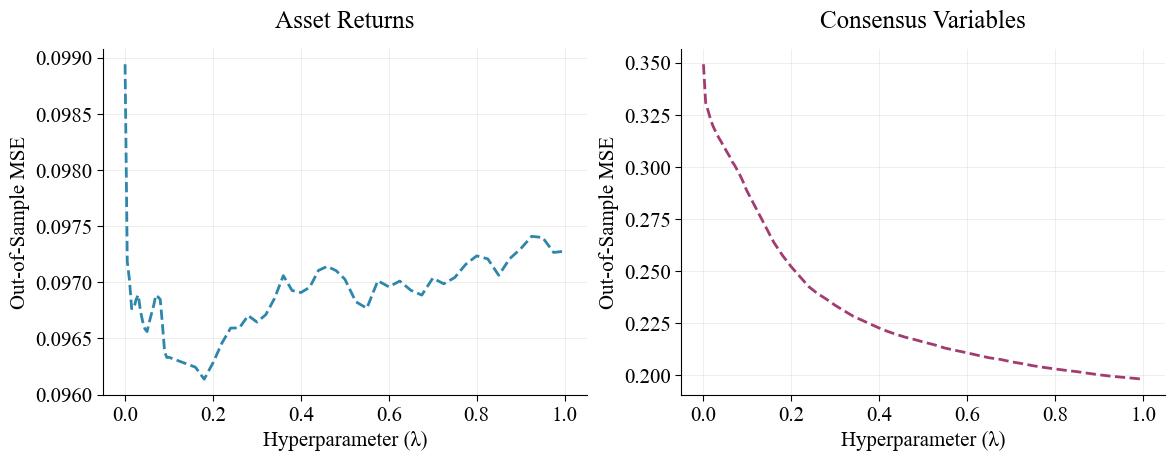

Plotting MSE for 12-month prediction horizon


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
EPS forecast revision,0.321160,0.311804,0.306377,0.304209,0.303448,0.302980,0.302531,0.302112,0.301788,0.301470,...,0.288975,0.288833,0.288729,0.288636,0.288550,0.288403,0.288301,0.288232,0.288147,0.288043
Change in recommendation,0.362891,0.342763,0.336442,0.334475,0.333572,0.332956,0.332399,0.331890,0.331537,0.331381,...,0.330599,0.330561,0.330563,0.330550,0.330541,0.330567,0.330516,0.330539,0.330544,0.330561
Change in Forecast and Accrual,0.439519,0.340918,0.313797,0.304121,0.300295,0.297881,0.295944,0.294526,0.293555,0.292809,...,0.281831,0.281656,0.281500,0.281390,0.281311,0.281082,0.281028,0.280933,0.280851,0.280741
Long-vs-short EPS forecasts,0.352339,0.338775,0.335527,0.333703,0.332450,0.331337,0.330399,0.329558,0.328854,0.328307,...,0.304704,0.304479,0.304307,0.304135,0.303959,0.303692,0.303496,0.303352,0.303207,0.302930
Analyst earnings per share,0.341818,0.328013,0.322078,0.316912,0.312036,0.307451,0.303389,0.300220,0.297291,0.294291,...,0.106284,0.104846,0.103529,0.102526,0.101586,0.098691,0.098004,0.097240,0.096388,0.095226
EPS Forecast Dispersion,0.353261,0.337753,0.330171,0.326513,0.323927,0.321354,0.318766,0.316447,0.314651,0.312461,...,0.209468,0.208668,0.207961,0.207321,0.206679,0.205197,0.204822,0.204320,0.203796,0.203127
Earnings forecast revisions,0.370501,0.344191,0.336646,0.332946,0.331239,0.329363,0.327458,0.326370,0.325091,0.323987,...,0.283506,0.283051,0.282592,0.282166,0.281820,0.280916,0.280599,0.280177,0.279790,0.279408
Analyst Value,0.371916,0.339519,0.331230,0.327070,0.325024,0.322988,0.321185,0.319417,0.318299,0.316882,...,0.223375,0.222197,0.221276,0.220335,0.219586,0.217844,0.217297,0.216684,0.216000,0.215177
Analyst Optimism,0.350397,0.335948,0.329943,0.325595,0.323039,0.320828,0.319048,0.317674,0.316528,0.315105,...,0.216584,0.215595,0.214742,0.213984,0.213261,0.211578,0.211116,0.210559,0.209929,0.209199


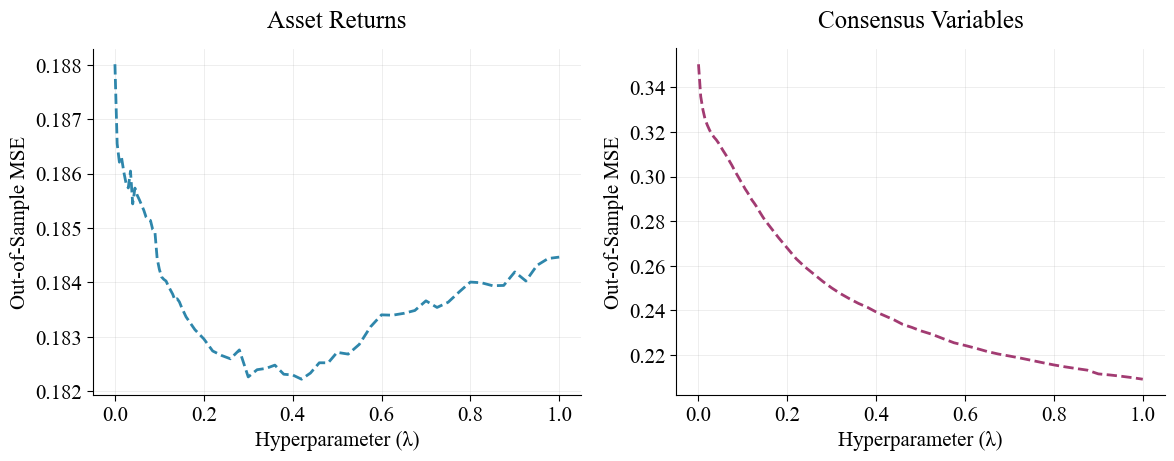

In [6]:
# out-of-sampe MSE
print("Plotting MSE for 1-month prediction horizon")
plot_mse(horizon='1month', mode = 'oos')

print("Plotting MSE for 3-month prediction horizon")
plot_mse(horizon='3month', mode = 'oos')

print("Plotting MSE for 6-month prediction horizon")
plot_mse(horizon='6month', mode = 'oos')

print("Plotting MSE for 12-month prediction horizon")
plot_mse(horizon='12month', mode = 'oos')

In [9]:
lambda_list_1month = get_lambda_list_for_horizon('1month')
lambda_list_12month = get_lambda_list_for_horizon('12month')

Plotting MSE for 1-month prediction horizon


In-sample MSE by lambda: 100%|██████████| 71/71 [3:37:35<00:00, 183.89s/it]  


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
EPS forecast revision,0.308479,0.302884,0.301731,0.300325,0.298777,0.297108,0.295591,0.293994,0.292929,0.291438,...,0.278632,0.278647,0.278537,0.278450,0.278431,0.278450,0.278438,0.278456,0.278463,0.278442
Change in recommendation,0.332545,0.330356,0.330211,0.330137,0.330118,0.330099,0.330079,0.330023,0.330005,0.329961,...,0.329641,0.329675,0.329669,0.329663,0.329666,0.329680,0.329692,0.329707,0.329722,0.329734
Change in Forecast and Accrual,0.310867,0.297004,0.295573,0.293964,0.292666,0.291278,0.290260,0.289019,0.288298,0.287308,...,0.276302,0.276285,0.276219,0.276117,0.276089,0.276050,0.276007,0.276019,0.276004,0.275959
Long-vs-short EPS forecasts,0.338491,0.331098,0.328037,0.323862,0.319317,0.314901,0.310574,0.306082,0.303424,0.299204,...,0.257445,0.257149,0.256790,0.256442,0.256182,0.256148,0.255894,0.255778,0.255671,0.255442
Analyst earnings per share,0.332414,0.313650,0.298428,0.282471,0.265064,0.248183,0.233505,0.218163,0.207064,0.192393,...,0.064371,0.064014,0.063670,0.063278,0.062959,0.062745,0.062455,0.062276,0.062025,0.061803
EPS Forecast Dispersion,0.339738,0.327778,0.322385,0.316804,0.310245,0.303329,0.294681,0.285945,0.280219,0.271229,...,0.184800,0.184310,0.183894,0.183553,0.183208,0.182789,0.182337,0.182040,0.181705,0.181361
Earnings forecast revisions,0.335537,0.330301,0.327573,0.324290,0.321184,0.318236,0.315491,0.312506,0.311387,0.308648,...,0.264794,0.264467,0.264093,0.263782,0.263525,0.263157,0.262832,0.262598,0.262321,0.262087
Analyst Value,0.337779,0.325820,0.319869,0.313458,0.307172,0.300414,0.293719,0.286126,0.281880,0.274975,...,0.189707,0.189129,0.188626,0.188176,0.187665,0.187160,0.186718,0.186388,0.186026,0.185686
Analyst Optimism,0.340460,0.327660,0.322219,0.316064,0.309022,0.301867,0.293414,0.283988,0.276525,0.267686,...,0.179307,0.178815,0.178369,0.177916,0.177503,0.177164,0.176793,0.176491,0.176145,0.175831
Consensus average MSE,0.330701,0.320728,0.316225,0.311264,0.305952,0.300602,0.295257,0.289538,0.285748,0.280316,...,0.225000,0.224721,0.224430,0.224153,0.223914,0.223705,0.223463,0.223306,0.223120,0.222927


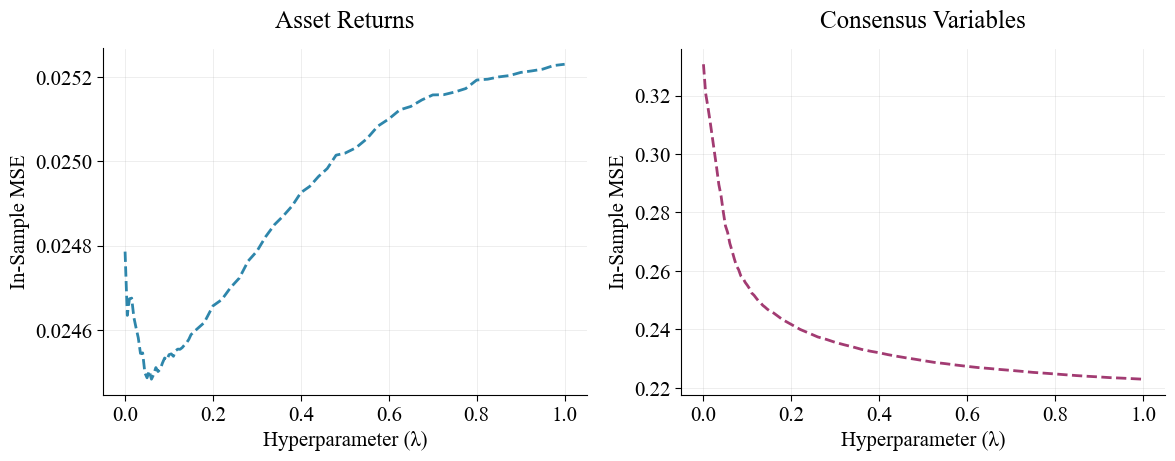

Plotting MSE for 12-month prediction horizon


In-sample MSE by lambda: 100%|██████████| 69/69 [3:18:56<00:00, 172.99s/it]  


,0.000,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,...,0.775,0.800,0.825,0.850,0.875,0.900,0.925,0.950,0.975,1.000
EPS forecast revision,0.320093,0.310141,0.305931,0.304067,0.303339,0.302599,0.302012,0.301422,0.300821,0.300346,...,0.281698,0.281530,0.281389,0.281273,0.281136,0.280941,0.280811,0.280706,0.280582,0.280443
Change in recommendation,0.356465,0.341541,0.337078,0.335989,0.335306,0.334851,0.334361,0.334028,0.333779,0.333629,...,0.331133,0.331114,0.331076,0.331045,0.331003,0.331038,0.330981,0.330979,0.330956,0.330946
Change in Forecast and Accrual,0.397736,0.328304,0.310044,0.303438,0.300965,0.299246,0.297874,0.296881,0.296261,0.295630,...,0.280777,0.280615,0.280491,0.280411,0.280290,0.280049,0.279972,0.279835,0.279744,0.279628
Long-vs-short EPS forecasts,0.356111,0.340555,0.334249,0.330757,0.328129,0.325450,0.323146,0.321440,0.320004,0.318626,...,0.266820,0.266459,0.266113,0.265766,0.265454,0.264778,0.264453,0.264139,0.263833,0.263417
Analyst earnings per share,0.343902,0.327267,0.316697,0.308219,0.301325,0.294220,0.288105,0.283578,0.279527,0.275451,...,0.088158,0.087190,0.086178,0.085420,0.084580,0.082503,0.081907,0.081272,0.080632,0.079818
EPS Forecast Dispersion,0.360830,0.341962,0.331514,0.326572,0.322101,0.318356,0.315320,0.312748,0.310445,0.308198,...,0.209837,0.209110,0.208442,0.207782,0.207163,0.205979,0.205480,0.205008,0.204531,0.203944
Earnings forecast revisions,0.349485,0.335807,0.331827,0.328647,0.326757,0.324971,0.323168,0.321920,0.320698,0.319519,...,0.275607,0.275254,0.274830,0.274442,0.274080,0.273358,0.273101,0.272720,0.272388,0.272006
Analyst Value,0.357916,0.339076,0.333106,0.328580,0.325528,0.322674,0.319984,0.317371,0.315577,0.313309,...,0.216798,0.215915,0.215108,0.214298,0.213585,0.212075,0.211583,0.210931,0.210263,0.209492
Analyst Optimism,0.364174,0.340526,0.329945,0.324508,0.320528,0.317537,0.314842,0.312478,0.310381,0.308349,...,0.201893,0.201108,0.200377,0.199686,0.199035,0.197637,0.197170,0.196643,0.196064,0.195433
Consensus average MSE,0.356301,0.333909,0.325599,0.321197,0.318220,0.315545,0.313201,0.311318,0.309721,0.308117,...,0.239191,0.238699,0.238223,0.237791,0.237370,0.236484,0.236162,0.235804,0.235444,0.235014


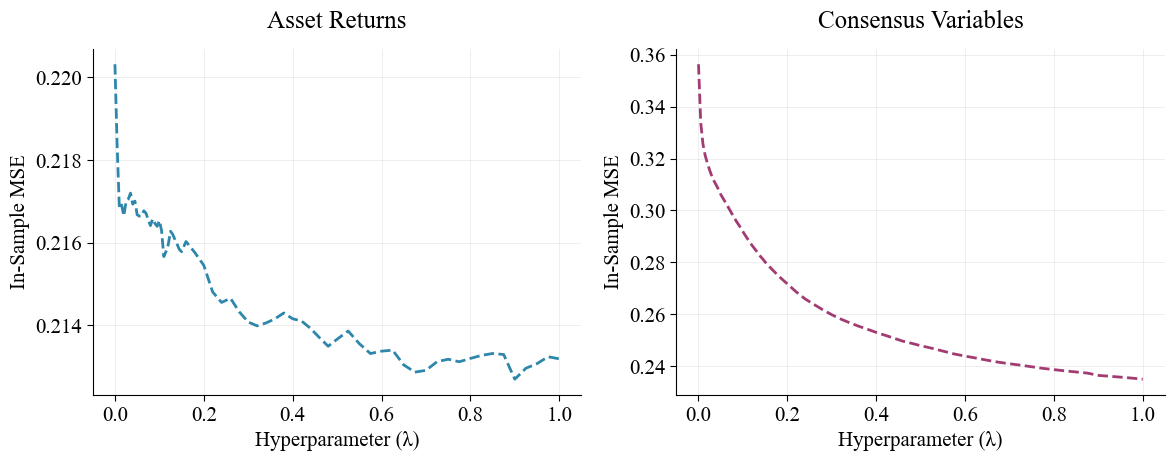

In [10]:
# in-sample MSE
print("Plotting MSE for 1-month prediction horizon")
plot_mse(horizon='1month', mode='is', lambda_list=lambda_list_1month)

print("Plotting MSE for 12-month prediction horizon")
plot_mse(horizon='12month', mode='is', lambda_list=lambda_list_12month)